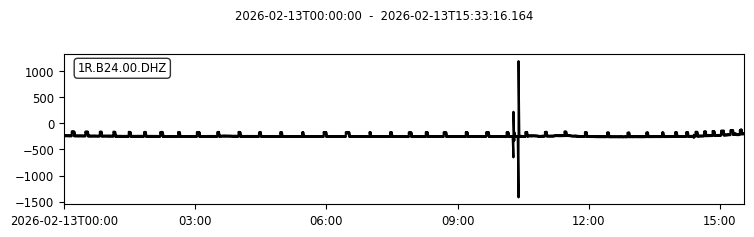

In [30]:
import obspy
st = obspy.read('/Volumes/classdata/KSC/20260310_service/20_archive/SDS/2026/1R/B24/DHZ.D/1R.B24.00.DHZ.D.2026.044')
st.plot();

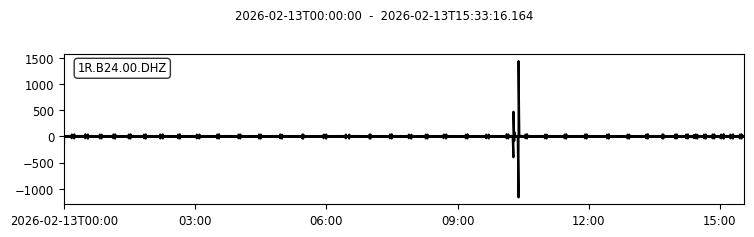

In [31]:
st2 = st.copy()
st2.filter('highpass', freq=0.1, corners=4, zerophase=True)
st2.plot();

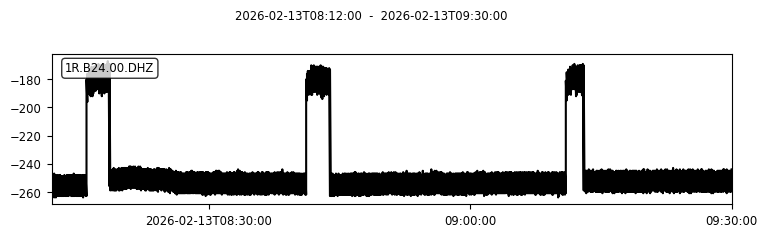

In [35]:
stime=st2[0].stats.starttime
st.plot(starttime=stime+8.2*3600, endtime=stime+9.5*3600);

[-242 -242 -244 ... -203 -206 -202] <class 'numpy.ndarray'>


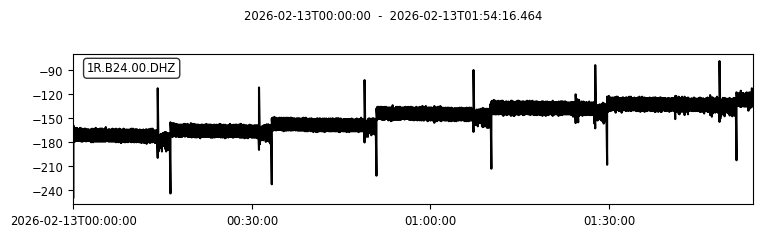

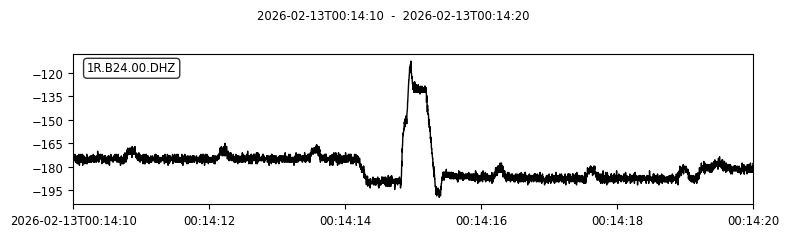

In [36]:
import numpy as np
from scipy.signal import medfilt


def remove_steps(
    x,
    window=101,
    threshold_sigma=8.0,
    min_step_samples=20,
    use_mad=True,
):
    """
    Remove step offsets from a 1-D signal.

    Parameters
    ----------
    x : array-like
        Input data.
    window : int
        Median filter window length. Must be odd.
    threshold_sigma : float
        Step detection threshold in units of local noise.
        Larger values detect only very obvious steps.
    min_step_samples : int
        Minimum spacing between detected steps.
    use_mad : bool
        If True, use MAD-based robust noise estimate.
        If False, use standard deviation.

    Returns
    -------
    corrected : ndarray
        Step-corrected signal.
    step_indices : ndarray
        Sample indices where steps were detected.
    step_offsets : ndarray
        Estimated offset added at each step.
    """

    x = np.asarray(x, dtype=float)
    corrected = x.copy()

    if window % 2 == 0:
        window += 1

    # Smooth signal to suppress ordinary noise
    smooth = medfilt(x, kernel_size=window)

    # First difference highlights steps
    dx = np.diff(smooth)

    # Estimate noise level from the derivative
    if use_mad:
        noise = 1.4826 * np.median(np.abs(dx - np.median(dx)))
    else:
        noise = np.std(dx)

    if noise == 0 or not np.isfinite(noise):
        return corrected, np.array([], dtype=int), np.array([])

    # Candidate step locations
    candidates = np.where(np.abs(dx) > threshold_sigma * noise)[0] + 1

    # Merge nearby detections
    step_indices = []
    for idx in candidates:
        if not step_indices or idx - step_indices[-1] >= min_step_samples:
            step_indices.append(idx)
        else:
            # Keep the strongest nearby candidate
            prev = step_indices[-1]
            if abs(dx[idx - 1]) > abs(dx[prev - 1]):
                step_indices[-1] = idx

    step_indices = np.array(step_indices, dtype=int)

    step_offsets = []

    # Estimate each step size using medians before and after the jump
    half_window = window // 2

    for idx in step_indices:
        left_start = max(0, idx - half_window)
        left_end = idx

        right_start = idx
        right_end = min(len(x), idx + half_window)

        left_med = np.nanmedian(corrected[left_start:left_end])
        right_med = np.nanmedian(corrected[right_start:right_end])

        step = right_med - left_med
        step_offsets.append(step)

        # Remove the offset from this point onward
        corrected[idx:] -= step

    return corrected, step_indices, np.array(step_offsets)

st3 = st.copy()
data = st3[0].data 
print(data, type(data))
#corrected, step_indices, offsets_array = remove_steps(data, window=1001, threshold_sigma=3)
st3[0].data = corrected
st3.plot();
st3.plot(starttime=stime+850, endtime=stime+860);


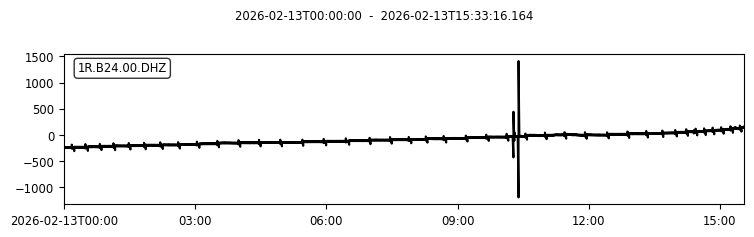

In [37]:
import numpy as np
from scipy.ndimage import median_filter


def remove_ramp_steps(
    x,
    fs,
    pre_window=1.0,
    post_window=1.0,
    search_window=0.2,
    threshold_sigma=8.0,
    min_gap=1.0,
):
    """
    Remove abrupt baseline shifts, including short ramps.

    Parameters
    ----------
    x : array-like
        1-D data.
    fs : float
        Sampling rate in Hz.
    pre_window, post_window : float
        Seconds used to estimate baseline before/after each candidate.
    search_window : float
        Seconds over which the ramp/transition may occur.
    threshold_sigma : float
        Required baseline change relative to data noise.
    min_gap : float
        Minimum seconds between detected corrections.

    Returns
    -------
    y : ndarray
        Corrected data.
    events : list of dict
        Detected ramp/step corrections.
    """

    x = np.asarray(x, dtype=float)
    y = x.copy()

    npre = int(pre_window * fs)
    npost = int(post_window * fs)
    nsearch = max(1, int(search_window * fs))
    mingap = int(min_gap * fs)

    # Robust noise estimate from first differences
    dx = np.diff(x)
    sigma = 1.4826 * np.median(np.abs(dx - np.median(dx)))

    if not np.isfinite(sigma) or sigma == 0:
        sigma = np.nanstd(dx)

    threshold = threshold_sigma * sigma

    events = []
    last_event = -mingap

    for i in range(npre, len(x) - npost - nsearch):

        if i - last_event < mingap:
            continue

        before = np.nanmedian(y[i - npre:i])
        after = np.nanmedian(y[i + nsearch:i + nsearch + npost])

        offset = after - before

        if abs(offset) > threshold:
            # Treat the transition as a ramp from i to i+nsearch
            i0 = i
            i1 = i + nsearch

            ramp = np.linspace(0, offset, i1 - i0)

            # Remove ramp part
            y[i0:i1] -= ramp

            # Remove full offset after ramp
            y[i1:] -= offset

            events.append(
                {
                    "start_index": i0,
                    "end_index": i1,
                    "offset": offset,
                    "threshold": threshold,
                }
            )

            last_event = i

    return y, events
st3 = st.copy()
tr = st3[0]
corrected, events = remove_ramp_steps(
    tr.data,
    fs=tr.stats.sampling_rate,
    pre_window=1.0,
    post_window=1.0,
    search_window=0.15,
    threshold_sigma=8.0,
    min_gap=1.0,
)
tr.data = corrected
tr.plot();